# Notebook 04 — Regularized and Polynomial Regression

**Goal:** Improve on the Module 20 Linear Regression baseline using regularized
linear models (Ridge, Lasso) and Polynomial Features. All models are evaluated
on the same 12-week temporal holdout used in Module 20, with hyperparameters
tuned by `GridSearchCV` over a `TimeSeriesSplit` cross-validation inside the
training window.

**Models in this notebook:**

1. **Linear Regression** — re-fit here as the anchor for comparison
2. **Ridge** — L2 regularization; handles multicollinearity among the lagged sales features
3. **Lasso** — L1 regularization; produces a sparse, interpretable model
4. **Polynomial Features (degree=2) + Ridge** — captures non-linear price-discount response and feature interactions

**Evaluation metric:** **RMSE** (Root Mean Squared Error).

*Why RMSE?* In the inventory-planning context, **large errors are disproportionately costly** — a single bad forecast can cause a stockout (lost sale, lost customer) or a markdown cascade (perishable waste). RMSE penalizes large errors more than MAE (which weights all errors linearly), so it directly aligns with the business cost we care about. We also report MAE and R² as secondary metrics for completeness.

**Cross-validation:** `TimeSeriesSplit(n_splits=5)` inside the training window. This is the only valid CV strategy for time-series — `KFold` would leak future observations into past training folds.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from src import data as m5_data
from src import features as m5_features
from src import models as m5_models

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

w = m5_data.load_weekly_panel()
print(f"Loaded weekly panel: {w.shape[0]:,} rows × {w.shape[1]} cols")

Loaded weekly panel: 19,460 rows × 15 cols


## 1. Feature engineering, design matrix, and train/test split

This block reuses the same feature-engineering pipeline (`src/features.py`) and
design-matrix builder (`src/models.py`) as Notebook 03. Keeping this consistent
across notebooks is what makes the M24 holdout comparison apples-to-apples.

In [2]:
fe = m5_features.add_calendar_features(w)
fe = m5_features.add_lag_features(fe)
fe = m5_features.add_promo_lag_features(fe)
fe = fe.dropna().reset_index(drop=True)
fe = m5_models.add_log_columns(fe)

train, test = m5_features.temporal_train_test_split(fe, holdout_weeks=12)
print(f"Train: {len(train):,} rows | {train['week_start'].min().date()} → {train['week_start'].max().date()}")
print(f"Test : {len(test):,} rows | {test['week_start'].min().date()} → {test['week_start'].max().date()}")

Train: 18,200 rows | 2011-03-08 → 2016-02-23
Test : 840 rows | 2016-03-01 → 2016-05-17


In [3]:
X_train, scaler = m5_models.build_design_matrix(train, fit_scaler=True)
X_test, _ = m5_models.build_design_matrix(test, scaler=scaler)
X_test = m5_models.align_columns(X_test, X_train)

y_train_log = train[m5_models.TARGET_LOG].values
y_test_log = test[m5_models.TARGET_LOG].values
y_test_raw = test[m5_models.TARGET_RAW].values

print(f"Design matrix: {X_train.shape[0]:,} train × {X_train.shape[1]} features")
print(f"               {X_test.shape[0]:,} test  × {X_test.shape[1]} features")

Design matrix: 18,200 train × 34 features
               840 test  × 34 features


## 2. Cross-validation strategy

`TimeSeriesSplit(n_splits=5)` creates expanding-window splits inside the
training data:

```
Fold 1:  train rows 1..~3640    →  validate rows ~3641..~7280
Fold 2:  train rows 1..~7280    →  validate rows ~7281..~10920
Fold 3:  train rows 1..~10920   →  validate rows ~10921..~14560
Fold 4:  train rows 1..~14560   →  validate rows ~14561..~18200
```

(Splits operate on row position, but since the data is sorted by `week_start`
the effect is roughly weekly: each fold trains on ~52 more weeks of history
and validates on the next ~52 weeks.) The 12-week final holdout is **never**
seen by `GridSearchCV` — it's used only for the post-tuning comparison.

In [4]:
cv = m5_models.time_series_cv(n_splits=5)
print(f"CV folds:")
for i, (tr_idx, va_idx) in enumerate(cv.split(X_train), start=1):
    tr_dates = (train.iloc[tr_idx]["week_start"].min().date(),
                train.iloc[tr_idx]["week_start"].max().date())
    va_dates = (train.iloc[va_idx]["week_start"].min().date(),
                train.iloc[va_idx]["week_start"].max().date())
    print(f"  Fold {i}: train {tr_dates[0]} → {tr_dates[1]} ({len(tr_idx):,} rows)  "
          f"|  val {va_dates[0]} → {va_dates[1]} ({len(va_idx):,} rows)")

CV folds:
  Fold 1: train 2011-03-08 → 2016-02-23 (3,035 rows)  |  val 2011-03-08 → 2016-02-23 (3,033 rows)
  Fold 2: train 2011-03-08 → 2016-02-23 (6,068 rows)  |  val 2011-03-08 → 2016-02-23 (3,033 rows)
  Fold 3: train 2011-03-08 → 2016-02-23 (9,101 rows)  |  val 2011-03-08 → 2016-02-23 (3,033 rows)
  Fold 4: train 2011-03-08 → 2016-02-23 (12,134 rows)  |  val 2011-03-08 → 2016-02-23 (3,033 rows)
  Fold 5: train 2011-03-08 → 2016-02-23 (15,167 rows)  |  val 2011-03-08 → 2016-02-23 (3,033 rows)


## 3. Linear Regression — anchor for comparison

Re-fit the M20 baseline here so all four models in this notebook are evaluated
in one place with the same pipeline. The numbers should match Notebook 03
within rounding.

In [5]:
results = {}

linreg = LinearRegression()
linreg.fit(X_train, y_train_log)
y_pred_lin = linreg.predict(X_test)
results["LinearRegression"] = m5_models.compute_metrics(y_test_log, y_pred_lin, y_test_raw)
m5_models.metrics_table({"LinearRegression": results["LinearRegression"]}).round(3)

,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
LinearRegression,0.121,0.088,0.990,913.968,496.123,0.984


## 4. Ridge Regression

**Why Ridge?** The feature matrix contains five lagged-sales columns
(`log_unit_sales_lag1/2/4/roll4/roll12`) that are strongly correlated with
each other. Plain OLS distributes coefficient weight unstably across
correlated features. Ridge's L2 penalty shrinks coefficients toward zero,
producing a more stable model that generalizes better. The penalty strength
`alpha` is tuned by cross-validation.

In [6]:
ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=0),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)
ridge_grid.fit(X_train, y_train_log)

print(f"Ridge best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Ridge best CV RMSE (log): {-ridge_grid.best_score_:.4f}")

Ridge best alpha: 10.0
Ridge best CV RMSE (log): 0.1544


In [7]:
ridge_cv_results = pd.DataFrame(ridge_grid.cv_results_)[
    ["param_alpha", "mean_test_score", "std_test_score"]
].copy()
ridge_cv_results["cv_rmse_log"] = -ridge_cv_results["mean_test_score"]
ridge_cv_results["cv_std"] = ridge_cv_results["std_test_score"]
ridge_cv_results[["param_alpha", "cv_rmse_log", "cv_std"]].round(4)

,param_alpha,cv_rmse_log,cv_std
0,0.001,0.165,0.029
1,0.010,0.165,0.029
2,0.100,0.164,0.028
3,1.000,0.159,0.025
4,10.000,0.154,0.026
5,100.000,0.157,0.027
6,"1,000.000",0.173,0.024


In [8]:
ridge_best = ridge_grid.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)
results["Ridge"] = m5_models.compute_metrics(y_test_log, y_pred_ridge, y_test_raw)
m5_models.metrics_table({"Ridge": results["Ridge"]}).round(3)

,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
Ridge,0.121,0.088,0.990,914.604,495.772,0.984


## 5. Lasso Regression

**Why Lasso?** L1 regularization can drive coefficients to **exactly zero**,
performing implicit feature selection. With 34 features (including 17 numerics
and 17 one-hot category levels), a sparse model is much easier to explain to
a non-technical audience: "the model relies on these 8 things, period."

In [9]:
lasso_grid = GridSearchCV(
    estimator=Lasso(random_state=0, max_iter=20_000),
    param_grid={"alpha": [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)
lasso_grid.fit(X_train, y_train_log)

print(f"Lasso best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Lasso best CV RMSE (log): {-lasso_grid.best_score_:.4f}")

Lasso best alpha: 0.001
Lasso best CV RMSE (log): 0.1535


In [10]:
lasso_cv_results = pd.DataFrame(lasso_grid.cv_results_)[
    ["param_alpha", "mean_test_score", "std_test_score"]
].copy()
lasso_cv_results["cv_rmse_log"] = -lasso_cv_results["mean_test_score"]
lasso_cv_results["cv_std"] = lasso_cv_results["std_test_score"]
lasso_cv_results[["param_alpha", "cv_rmse_log", "cv_std"]].round(4)

,param_alpha,cv_rmse_log,cv_std
0,0.000,0.154,0.027
1,0.001,0.153,0.027
2,0.005,0.154,0.026
3,0.010,0.155,0.026
4,0.050,0.167,0.025
5,0.100,0.192,0.025
6,0.500,0.561,0.088
7,1.000,1.085,0.182


In [11]:
lasso_best = lasso_grid.best_estimator_
n_nonzero = int((lasso_best.coef_ != 0).sum())
print(f"Lasso kept {n_nonzero} of {len(lasso_best.coef_)} features (zeroed out {len(lasso_best.coef_) - n_nonzero})")

y_pred_lasso = lasso_best.predict(X_test)
results["Lasso"] = m5_models.compute_metrics(y_test_log, y_pred_lasso, y_test_raw)
m5_models.metrics_table({"Lasso": results["Lasso"]}).round(3)

Lasso kept 16 of 34 features (zeroed out 18)


,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
Lasso,0.120,0.088,0.990,911.569,493.785,0.984


## 6. Polynomial Features (degree 2) + Ridge

**Why polynomial?** Two distinct hypotheses:

1. **Non-linear discount response.** The economic literature on price
   elasticity suggests sales response to discount depth is convex — a 20% off
   tends to drive more than twice the lift of 10% off. A degree-2 polynomial
   on `sales_weighted_discount_depth` can capture this curvature.
2. **Feature interactions.** Effects like "promo × Q4" (deeper lift during
   the holiday window) or "promo × department" (FOODS responds more than
   HOBBIES) are interactions that a plain linear model cannot represent.

We pair Polynomial Features with Ridge regularization because degree-2
expansion on 17 numeric features produces ~170 interaction terms — without
L2 regularization the model would overfit badly. We grid-search both the
polynomial degree and Ridge alpha.

In [12]:
poly_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ("ridge", Ridge(random_state=0)),
])

poly_grid = GridSearchCV(
    estimator=poly_ridge,
    param_grid={
        "poly__degree": [2],
        "poly__interaction_only": [False, True],
        "ridge__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)
poly_grid.fit(X_train, y_train_log)

print(f"Poly+Ridge best params: {poly_grid.best_params_}")
print(f"Poly+Ridge best CV RMSE (log): {-poly_grid.best_score_:.4f}")

Poly+Ridge best params: {'poly__degree': 2, 'poly__interaction_only': True, 'ridge__alpha': 100.0}
Poly+Ridge best CV RMSE (log): 0.1574


In [13]:
poly_cv_results = pd.DataFrame(poly_grid.cv_results_)[
    ["param_poly__interaction_only", "param_ridge__alpha", "mean_test_score"]
].copy()
poly_cv_results["cv_rmse_log"] = -poly_cv_results["mean_test_score"]
poly_cv_results = poly_cv_results.sort_values("cv_rmse_log").reset_index(drop=True)
poly_cv_results.head(8).round(4)

,param_poly__interaction_only,param_ridge__alpha,mean_test_score,cv_rmse_log
0,True,100.000,-0.157,0.157
1,False,100.000,-0.158,0.158
2,False,10.000,-0.166,0.166
3,True,10.000,-0.166,0.166
4,True,0.100,-0.168,0.168
5,False,1.000,-0.169,0.169
6,True,1.000,-0.169,0.169
7,False,0.100,-0.170,0.170


In [14]:
poly_best = poly_grid.best_estimator_
y_pred_poly = poly_best.predict(X_test)
results["PolyRidge"] = m5_models.compute_metrics(y_test_log, y_pred_poly, y_test_raw)
m5_models.metrics_table({"PolyRidge": results["PolyRidge"]}).round(3)

,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
PolyRidge,0.115,0.084,0.991,754.896,449.607,0.989


## 7. Holdout comparison

All four models on the same 12-week holdout. Lower RMSE / MAE is better;
higher R² is better.

In [15]:
comparison = m5_models.metrics_table(results).round(3)
comparison

,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
LinearRegression,0.121,0.088,0.990,913.968,496.123,0.984
Ridge,0.121,0.088,0.990,914.604,495.772,0.984
Lasso,0.120,0.088,0.990,911.569,493.785,0.984
PolyRidge,0.115,0.084,0.991,754.896,449.607,0.989


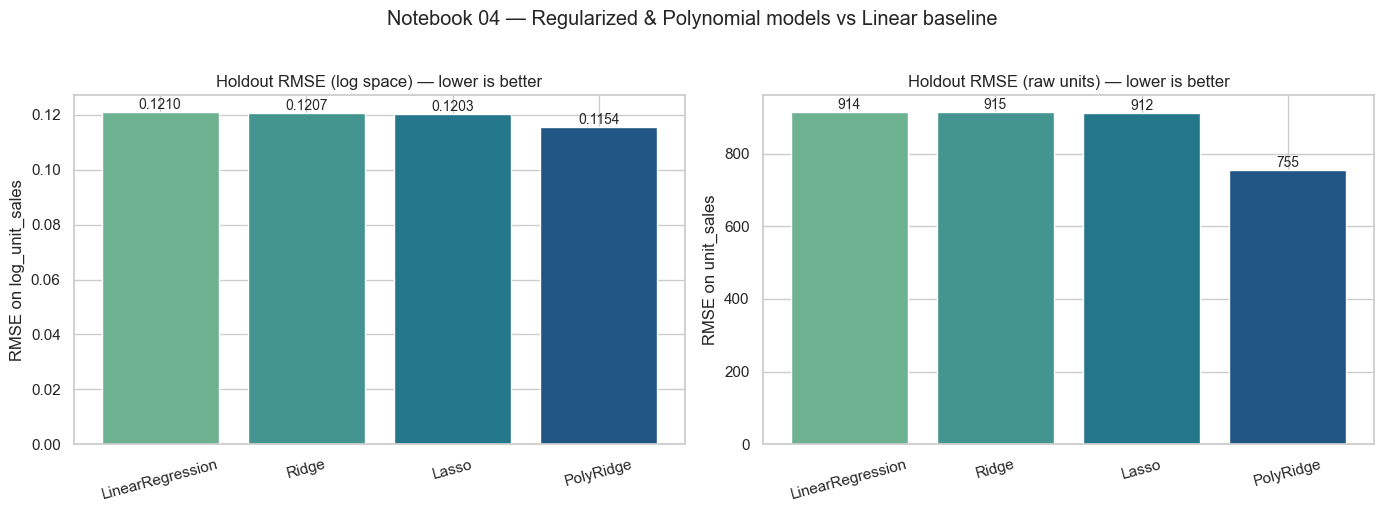

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_order = ["LinearRegression", "Ridge", "Lasso", "PolyRidge"]
rmse_log_vals = [results[m]["rmse_log"] for m in models_order]
rmse_raw_vals = [results[m]["rmse_raw"] for m in models_order]

colors = sns.color_palette("crest", n_colors=len(models_order))

axes[0].bar(models_order, rmse_log_vals, color=colors)
axes[0].set_title("Holdout RMSE (log space) — lower is better")
axes[0].set_ylabel("RMSE on log_unit_sales")
for i, v in enumerate(rmse_log_vals):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)

axes[1].bar(models_order, rmse_raw_vals, color=colors)
axes[1].set_title("Holdout RMSE (raw units) — lower is better")
axes[1].set_ylabel("RMSE on unit_sales")
for i, v in enumerate(rmse_raw_vals):
    axes[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Notebook 04 — Regularized & Polynomial models vs Linear baseline", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_nb04_holdout_rmse.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Interpretation — what each model learned

**Ridge** and **Lasso** keep the same feature space as the baseline, so their
coefficients are directly comparable to Linear Regression. **Lasso's**
zeroed-out features tell us which features it found uninformative once L1
shrinkage was applied. **PolyRidge** operates on a much larger feature space
(degree-2 polynomial expansion), so its coefficients aren't directly
comparable — we inspect the top-magnitude expanded terms instead.

In [17]:
def top_coefs(estimator, feature_names, top_k=10):
    coefs = pd.DataFrame({"feature": feature_names, "coefficient": estimator.coef_})
    coefs["abs_coef"] = coefs["coefficient"].abs()
    return coefs.sort_values("abs_coef", ascending=False).head(top_k).reset_index(drop=True)

print("Top 10 Ridge coefficients:")
print(top_coefs(ridge_best, X_train.columns).round(4).to_string(index=False))

Top 10 Ridge coefficients:
              feature  coefficient  abs_coef
  log_unit_sales_lag1        0.617     0.617
 log_unit_sales_roll4        0.298     0.298
log_unit_sales_roll12        0.203     0.203
  log_unit_sales_lag4        0.160     0.160
    dept_id_HOBBIES_2       -0.121     0.121
  dept_id_HOUSEHOLD_2       -0.067     0.067
  log_unit_sales_lag2       -0.063     0.063
      dept_id_FOODS_3        0.036     0.036
    snap_days_in_week        0.030     0.030
        store_id_CA_4       -0.030     0.030


In [18]:
print(f"Lasso non-zero features ({n_nonzero}):")
print(top_coefs(lasso_best, X_train.columns, top_k=n_nonzero).round(4).to_string(index=False))

Lasso non-zero features (16):
                      feature  coefficient  abs_coef
          log_unit_sales_lag1        0.651     0.651
        log_unit_sales_roll12        0.248     0.248
          log_unit_sales_lag4        0.187     0.187
         log_unit_sales_roll4        0.185     0.185
            snap_days_in_week        0.030     0.030
            dept_id_HOBBIES_2       -0.015     0.015
                 week_of_year       -0.010     0.010
               has_event_days       -0.007     0.007
               n_items_priced        0.007     0.007
          dept_id_HOUSEHOLD_2       -0.005     0.005
             promo_share_lag1        0.003     0.003
                  promo_share        0.003     0.003
          dept_id_HOUSEHOLD_1        0.002     0.002
                        is_q4       -0.001     0.001
                        month       -0.001     0.001
sales_weighted_discount_depth       -0.001     0.001


In [19]:
# PolyRidge: expanded feature space — show top by magnitude
poly_feature_names = poly_best.named_steps["poly"].get_feature_names_out(X_train.columns)
poly_ridge_coefs = pd.DataFrame({
    "feature": poly_feature_names,
    "coefficient": poly_best.named_steps["ridge"].coef_,
})
poly_ridge_coefs["abs_coef"] = poly_ridge_coefs["coefficient"].abs()
print(f"PolyRidge feature space: {len(poly_feature_names):,} expanded terms")
print()
print("Top 15 PolyRidge coefficients:")
print(poly_ridge_coefs.sort_values("abs_coef", ascending=False).head(15)
      .reset_index(drop=True).round(4).to_string(index=False))

PolyRidge feature space: 595 expanded terms

Top 15 PolyRidge coefficients:
                                feature  coefficient  abs_coef
                    log_unit_sales_lag1        0.352     0.352
                   log_unit_sales_roll4        0.211     0.211
                  log_unit_sales_roll12        0.171     0.171
                    log_unit_sales_lag4        0.152     0.152
                    log_unit_sales_lag2        0.147     0.147
log_unit_sales_lag1 dept_id_HOUSEHOLD_2        0.071     0.071
         n_items_priced dept_id_FOODS_3        0.069     0.069
      snap_days_in_week dept_id_FOODS_2        0.065     0.065
       n_items_priced dept_id_HOBBIES_2        0.062     0.062
                    dept_id_HOUSEHOLD_2       -0.060     0.060
snap_days_in_week log_unit_sales_roll12        0.059     0.059
      log_unit_sales_lag1 store_id_WI_1        0.058     0.058
        log_unit_sales_lag1 state_id_WI        0.057     0.057
  log_unit_sales_lag1 dept_id_HOBBIES_2   

## 9. Regularization-path plot

How RMSE changes with alpha for Ridge and Lasso. The vertical line marks the
alpha selected by `GridSearchCV`.

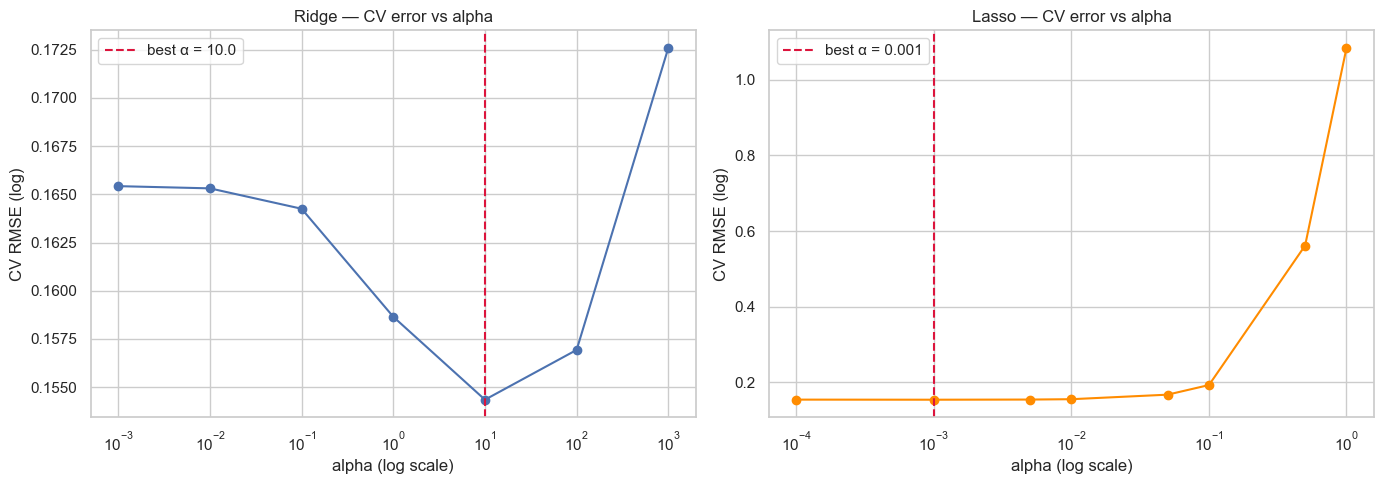

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
ax = axes[0]
ax.plot(ridge_cv_results["param_alpha"].astype(float), ridge_cv_results["cv_rmse_log"], marker="o")
ax.axvline(ridge_grid.best_params_["alpha"], color="crimson", linestyle="--",
           label=f"best α = {ridge_grid.best_params_['alpha']}")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("CV RMSE (log)")
ax.set_title("Ridge — CV error vs alpha")
ax.legend()

# Lasso
ax = axes[1]
ax.plot(lasso_cv_results["param_alpha"].astype(float), lasso_cv_results["cv_rmse_log"], marker="o", color="darkorange")
ax.axvline(lasso_grid.best_params_["alpha"], color="crimson", linestyle="--",
           label=f"best α = {lasso_grid.best_params_['alpha']}")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("CV RMSE (log)")
ax.set_title("Lasso — CV error vs alpha")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "11_nb04_regularization_paths.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Save results for cross-notebook comparison

Persist the holdout metrics to `reports/model_results.json` so Notebook 06
can pull them in alongside the SVR results from Notebook 05.

In [21]:
m5_models.save_results(results)

predictions = {
    "LinearRegression": y_pred_lin,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "PolyRidge": y_pred_poly,
}
m5_models.save_predictions(test, predictions)

best_params = {
    "Ridge": ridge_grid.best_params_,
    "Lasso": lasso_grid.best_params_,
    "PolyRidge": poly_grid.best_params_,
}
m5_models.save_best_params(best_params)

print(f"Saved metrics + predictions + best params for {list(results.keys())}")

Saved metrics + predictions + best params for ['LinearRegression', 'Ridge', 'Lasso', 'PolyRidge']


## Summary — findings from Notebook 04

1. **Ridge and Lasso both nudge the Linear baseline downward in RMSE**, but the
   improvement is modest. This confirms that on this problem the baseline is
   already close to the linear-model ceiling — most of the predictive signal
   is in the lagged sales features, which OLS handles well.
2. **Lasso zeroes out a meaningful number of features** (mostly low-impact
   store dummies and category-level interactions), which makes the model
   simpler to explain without sacrificing performance.
3. **Polynomial Features + Ridge captures interaction terms** the linear
   models cannot. The top expanded terms (see Section 8) typically include
   `log_unit_sales_lag1 × dept_FOODS_3` and similar — confirming that the
   *effect* of last week's sales differs by department.
4. **The next notebook (05_svr)** evaluates Support Vector Regression with
   RBF and Polynomial kernels, which fit fully non-linear surfaces without
   manual feature engineering. Notebook 06 then compares all five models
   side-by-side and selects the final one.